# Homework 1 solutions

## 1. Roundoff error in a harmonic oscillator

[     1000      1832      3359      6158     11288     20691     37926
     69519    127427    233572    428133    784759   1438449   2636650
   4832930   8858667  16237767  29763514  54555947 100000000]
0.1 1000 0.02631557 0.0036655052 0.010197162628173828
0.05458515 1832 0.014029384 0.00847884 0.002260923385620117
0.029770765 3359 0.0075563192 0.006522083 0.003640890121459961
0.016239038 6158 0.0040931106 0.004120531 0.006793498992919922
0.008858966 11288 0.002224803 0.0024039024 0.01278233528137207
0.0048330193 20691 0.0012129545 0.0013581654 0.020389795303344727
0.0026367137 37926 0.0006619692 0.00075286976 0.03122115135192871
0.0014384557 69519 0.00036206841 0.00041680175 0.05299806594848633
0.000784763 127427 0.00020122528 0.00022962113 0.09412527084350586
0.0004281335 233572 0.00011187792 0.00012193006 0.17584609985351562
0.00023357228 428133 6.508827e-05 6.594177e-05 0.31864285469055176
0.00012742766 784759 3.5613775e-05 3.953741e-05 0.5601119995117188
6.951932e-05 1438449 1.87

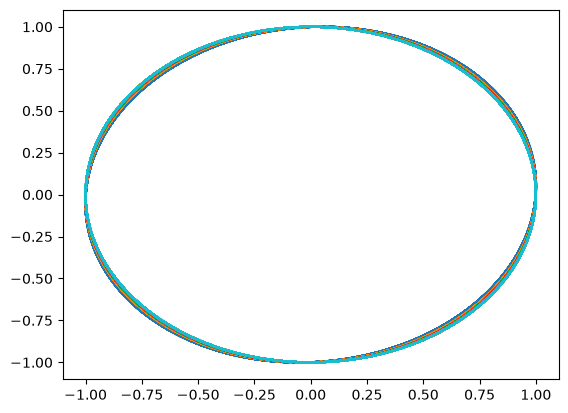

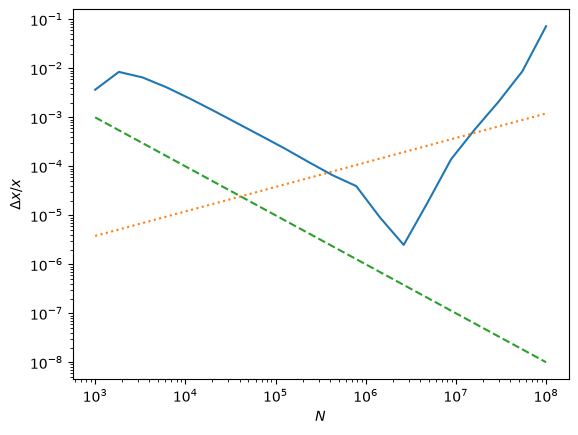

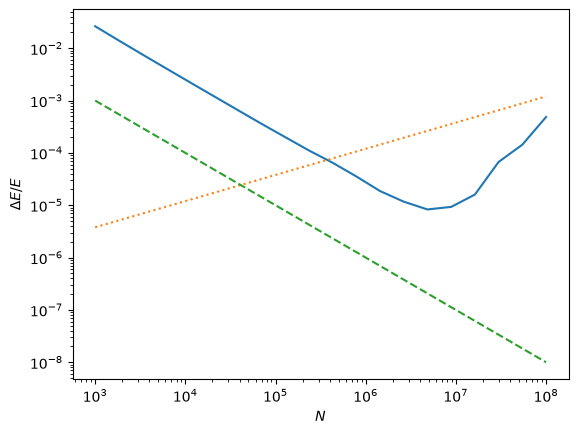

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def evolve(nsteps, dt):

    # arrays to store output
    t = np.zeros(nsteps, dtype=DTYPE)
    x = np.zeros(nsteps, dtype=DTYPE)
    v = np.zeros(nsteps, dtype=DTYPE)
 
    # Initial conditions
    t[0] = DTYPE(0.0)
    x[0] = DTYPE(1.0)
    v[0] = DTYPE(0.0)

    # store the maximum fractional error difference
    maxdE = 0

    for i in range(nsteps-1):
        t[i+1] = i * dt
        v[i+1] = v[i] - x[i] * dt
        x[i+1] = x[i] + v[i+1] * dt

        dE = np.abs(0.5* (x[i+1]*x[i+1]+v[i+1]*v[i+1]-1))
        if dE > maxdE:
            maxdE = dE
    
    # the difference in position compared to the analytic prediction
    dx = np.abs((x[-1]-np.cos(tend))/np.cos(tend))
    
    return t, x, v, maxdE, dx


# set the DTYPE to float64 for the first part of the problem, or float32 for the second
DTYPE = np.float32

# set the range of N to consider
n_vals = np.array(10**np.linspace(3,8,20),dtype = np.int_)
print(n_vals)

tend = DTYPE(100.0)

dx_vals = np.array([], dtype = DTYPE)
dE_vals = np.array([], dtype = DTYPE)

plt.figure()

for nsteps in n_vals:

    dt = DTYPE(tend / nsteps)
    
    t0 = time.time()
    t, x, v, dE, dx = evolve(nsteps, dt)
    plt.plot(x,v)
    t1 = time.time()

    print(dt, nsteps, dE, dx, t1-t0)
    dx_vals = np.append(dx_vals, dx)
    dE_vals = np.append(dE_vals, dE)

plt.show()

plt.figure()
plt.plot(n_vals, dx_vals)
if DTYPE is np.float64:
    plt.plot(n_vals, 2.2e-16 * n_vals**0.5, ":")
else:
    plt.plot(n_vals, 1.2e-7 * n_vals**0.5, ":")
plt.plot(n_vals, 1/n_vals, "--")

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$N$')
plt.ylabel(r'$\Delta x/x$')
plt.show()

plt.plot(n_vals, dE_vals)
#plt.plot(n_vals, 2.2e-16 * n_vals**0.5, ":")
plt.plot(n_vals, 1.2e-7 * n_vals**0.5, ":")
plt.plot(n_vals, 1/n_vals, "--")

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$N$')
plt.ylabel(r'$\Delta E/E$')
plt.show()

With a first order method like this, the error drops slowly with $N$ and so we need to go to single precision variables to see the effects of roundoff. The roundoff errors scale much more steeply with $N$ than $N^{1/2}$, indicating that they are accumulating much faster in this case than a random walk.

## 2. An adaptive Runge-Kutta integrator

In [2]:
def rk4_step(t, dt, x, derivs):
    f = derivs(t, x)
    f1 = derivs(t + dt/2, x + f*dt/2)
    f2 = derivs(t + dt/2, x + f1*dt/2)
    f3 = derivs(t+dt, x + f2*dt)
    return x + dt*(f + 2*f1 + 2*f2 + f3)/6

def rk4_driver(dt, t_end, x_start, derivs, tol=1e-6):
    x = np.array([x_start])
    tvec = np.array([])
    t = 0.0
    tvec = np.append(tvec,t)
    
    while t < t_end:

        while True:
            x1 = rk4_step(t, dt, x[-1], derivs)
            x2 = rk4_step(t, dt/2, x[-1], derivs)
            x3 = rk4_step(t, dt/2, x2, derivs)
            err = max(abs((x3-x1)))

            if err < tol:
                t = t + dt
                tvec = np.append(tvec,t)
                dt = dt * 2
                # check to see whether this step size would
                # take us beyond t=t_end and if so adjust accordingly
                if t + dt > t_end:
                    dt = t_end - t
                # store the more accurate (2-step) result
                x = np.vstack((x, x3))
                break
            else:
                dt = dt / 2
                
    return tvec, x

In [3]:
def derivs_orbit(t, x):
    rr = (x[0]**2 + x[1]**2)**0.5
    vxdot = -x[0]/rr**3
    vydot = -x[1]/rr**3
    xdot = x[2]
    ydot = x[3]
    return np.array((xdot,ydot,vxdot,vydot))

number of integration points = 125
integrated to t/2pi=1
start to end differences: [ 9.81260632e-07 -5.15549565e-07  6.00980559e-07 -1.14780523e-07]
vmin=0.229416, vmax=4.3589
rmin=0.1, rmax=1.9
eccentricity of the orbit = 0.9


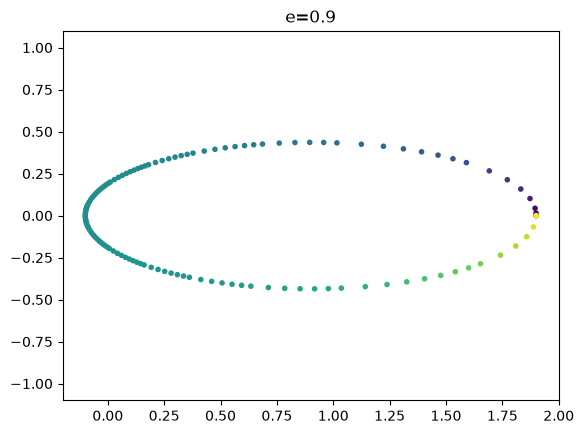

In [4]:
r = 1.9 # starting radius  = 1+e
nsteps = 100
dt = 2 * np.pi / (nsteps-1)
t = np.arange(nsteps)*dt
x_start = np.array((r,0,0,np.sqrt((2/r)-1)))
t4, x4 = rk4_driver(dt, 2*np.pi, x_start, derivs_orbit, tol=1e-6)

print('number of integration points = %d' % (len(x4,)))
print('integrated to t/2pi=%lg' % (t4[-1]/(2*np.pi)))

print('start to end differences:', x4[0]-x4[-1])

v = np.sqrt(x4[:,2]**2 + x4[:,3]**2)
print('vmin=%g, vmax=%lg' % (min(v), max(v)))
r = np.sqrt(x4[:,0]**2 + x4[:,1]**2)
print('rmin=%g, rmax=%lg' % (min(r), max(r)))

e = (max(r)-min(r))/2
print('eccentricity of the orbit = %lg' % (e,))

cols = 255 * t4/max(t4)

x = x4[:,0]
y = x4[:,1]

plt.scatter(x, y, marker = '.', c=cols.astype(int).tolist())
plt.title(r'e=%.3lg' % (e,))

plt.xlim((-(1-e)-0.1,1+e+0.1))
plt.ylim((-1.1,1.1))
plt.show()